# VolGAN — Implémentation inspirée sur données ORATS  
## D'après Vuletić & Cont (2024), *Applied Mathematical Finance*
### Magistère BFA - Dauphine - Jules Aubignat & Pablo Vicente

Implémentation d'un GAN conditionnel pour la modélisation de surfaces de volatilité implicite, inspirée du papier VolGAN.
Les données utilisées sont des surfaces ORATS réelles sur le **SPY** (S&P 500 ETF).
On suit la structure générale du papier : données → preprocessing → entraînement GAN → évaluation.

### Positionnement par rapport au papier

Ce projet est une **implémentation inspirée** du papier VolGAN (Vuletić & Cont, 2024), et non une reproduction exacte. Le tableau ci-dessous résume les choix effectués.

| Aspect | Papier | Ce projet |
|---|---|---|
| **Données** | OptionMetrics (SPX), ~20 ans | ORATS (SPY), ~1 400 jours |
| **Lissage** | Nadaraya–Watson (Section 4.1) | Non nécessaire : ORATS fournit `smvVol` déjà lissée |
| **Grille** | Haute résolution | 9 moneyness × 5 maturités = 45 points |
| **Architecture** | MLP conditionnel (G + D) | Idem, taille réduite (~3 400 + 1 500 params) |
| **Pénalités** | Sobolev $L_m$, $L_\tau$ + GNM | Idem |
| **Repondération** | WMC, β adaptatif (Eq. 20) | Idem |
| **Évaluation** | PCA, corrélations, arbitrage, couverture | Idem (hors hedging) |
| **Hedging / VIX** | Reproduit | Non reproduit |

**En résumé :** on reprend la méthodologie générale (GAN conditionnel + pénalités de régularité + repondération de scénarios), mais sur un dataset plus contraint. Le MLP est dimensionné en conséquence.

## 0. Imports et configuration

On importe les dépendances standard ainsi que le module `Projet_VOLGAN.py` qui contient l'architecture (Generator, Discriminator), les pénalités (Sobolev, arbitrage), et les fonctions d'entraînement et d'évaluation.

In [1]:
import os, glob, copy, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.decomposition import PCA

import Projet_VOLGAN as pv
from Projet_VOLGAN import (
    configure_grid, set_seeds,
    Normalizer, Generator, Discriminator,
    sobolev_penalties, arbitrage_penalty,
    gradient_norm_matching, train_volgan,
    scenario_reweighting, weighted_expectation, weighted_quantile,
    evaluate_pca, evaluate_correlations, evaluate_arbitrage_penalty,
)

warnings.filterwarnings("ignore")
set_seeds(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

Device : cpu


## 1. Grille (moneyness, maturité)

Le papier (Section 4.1) utilise une grille fixe sur laquelle on évalue la surface de vol implicite.
On adapte légèrement la grille pour coller à nos données ORATS.

**Convention d'indexation** (importante pour toute la suite) :
$$g\_\mathrm{flat}[b, i\cdot N_\tau + j] \leftrightarrow g[b, \mathrm{moneyness}_i, \mathrm{maturity}_j]$$
La maturité varie le plus vite (C-order, comme dans Projet_VOLGAN.py).

In [2]:
# Grille 9×5 = 45 points (on étend légèrement vs la grille 7×5 du module de base)
# pour avoir plus de couverture en moneyness sur les données SPY
MONEYNESS_GRID  = np.array([0.70, 0.80, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20, 1.30])
MATURITY_GRID   = np.array([1/52, 1/12, 1/4, 1/2, 1.0])   # en années (trading days : τ = dte/252)

N_M_   = len(MONEYNESS_GRID)   # 9
N_TAU_ = len(MATURITY_GRID)    # 5
SURF_DIM_ = N_M_ * N_TAU_      # 45

# ATM : m=1.0 (index 4), τ=1/4 (index 2) → flat index = 4*5+2 = 22
ATM_M_IDX_   = 4
ATM_TAU_IDX_ = 2
ATM_IDX_     = ATM_M_IDX_ * N_TAU_ + ATM_TAU_IDX_

print(f"Grille : {N_M_} moneyness × {N_TAU_} maturités = {SURF_DIM_} points")
print(f"ATM flat index : {ATM_IDX_}  (m={MONEYNESS_GRID[ATM_M_IDX_]}, τ={MATURITY_GRID[ATM_TAU_IDX_]:.4f})")

# Vérification de la bijection flat ↔ 2D
g_test = np.arange(SURF_DIM_).reshape(N_M_, N_TAU_)
for i in range(N_M_):
    for j in range(N_TAU_):
        assert g_test[i, j] == i * N_TAU_ + j
print("✓ Indexation grille OK")

Grille : 9 moneyness × 5 maturités = 45 points
ATM flat index : 22  (m=1.0, τ=0.2500)
✓ Indexation grille OK


## 2. Chargement des données ORATS

Chaque fichier parquet correspond à **un jour de trading** pour le SPY.
La colonne `smvVol` (ORATS Smoothed Implied Volatility) est déjà interpolée et lissée par ORATS — on n'a donc pas besoin de refaire le lissage Nadaraya–Watson du papier (Section 4.1).

On calcule :
- la **moneyness** $m = \mathrm{strike} / \mathrm{stockPrice}$
- la **maturité** $\tau = \mathrm{dte} / 252$ (convention jours de trading)

Puis on interpole bilinéairement sur notre grille cible $(m_i, \tau_j)$.

**Note :** Malgré un travail de preprocessing de la part du fournisseur de données, il reste du bruit dans les datas. De ce fait, une proportion significative de fichiers est filtrée (options illiquides, delta hors bornes, données insuffisantes pour une interpolation fiable). 

In [3]:
def load_single_day(filepath: str):
    """
    Charge un fichier parquet ORATS pour un jour donné.
    Retourne un dict (date, ticker, spot, rate, df) ou None si invalide.
    """
    try:
        df = pd.read_parquet(filepath)
    except Exception as e:
        print(f"Erreur lecture {filepath} : {e}")
        return None
    if df.empty:
        return None
    # Filtres de qualité : smvVol valide (cap vol max 200%), delta dans [0.05, 0.95] pour éviter les outliers sur les options deep OTM
    df = df[(df["smvVol"] > 0.01) & (df["smvVol"] < 2.0)]
    df = df[(df["delta"].abs() >= 0.05) & (df["delta"].abs() <= 0.95)]
    if len(df) < 10:
        return None
    spot = df["stockPrice"].iloc[0]
    df = df.copy()
    df["m"]   = (df["strike"] / spot).round(4)
    df["tau"] = df["dte"] / 252.0
    df["m_round"] = df["m"].round(3)
    df = df.drop_duplicates(subset=["m_round", "tau"]).drop(columns=["m_round"])
    return {
        "date":   df["tradeDate"].iloc[0],
        "ticker": df["ticker"].iloc[0],
        "spot":   spot,
        "rate":   float(df["residualRate"].median()) if "residualRate" in df.columns else 0.0,
        "df":     df[["m", "tau", "smvVol", "vega"]].reset_index(drop=True),
    }

In [4]:
def interpolate_surface(df_raw: pd.DataFrame):
    """
    Interpole la surface smvVol sur MONEYNESS_GRID × MATURITY_GRID.
    Utilise griddata (linéaire + nearest pour les extrapolations).
    Returns : array shape (SURF_DIM_,) ou None si échec.
    """
    from scipy.interpolate import griddata
    points = df_raw[["m", "tau"]].values
    values = df_raw["smvVol"].values
    mm, tt = np.meshgrid(MONEYNESS_GRID, MATURITY_GRID, indexing="ij")
    grid_points = np.column_stack([mm.ravel(), tt.ravel()])
    surf = griddata(points, values, grid_points, method="linear")
    mask_nan = np.isnan(surf)
    if mask_nan.any():
        surf_nn = griddata(points, values, grid_points, method="nearest")
        surf[mask_nan] = surf_nn[mask_nan]
    if np.isnan(surf).any() or (surf <= 0).any():
        return None
    return surf

In [5]:
def load_all_days(data_dir: str, ticker: str = None):
    """
    Charge tous les parquets dans data_dir, trie chronologiquement.
    Ne conserve que les jours avec date >= 01/09/2020. (Date de début de la série ORATS)
    Returns : (surfaces, log_returns, dates) avec surfaces en log-vol.
    """
    min_date = pd.Timestamp("2020-09-01")
    files = sorted(glob.glob(os.path.join(data_dir, "*.parquet")))
    print(f"Fichiers trouvés : {len(files)}")
    raw_days = []
    n_errors = 0
    for f in tqdm(files, desc="Chargement"):
        day = load_single_day(f)
        if day is None:
            n_errors += 1
            continue
        if pd.Timestamp(day["date"]) < min_date:
            continue
        if ticker and day["ticker"] != ticker:
            continue
        surf = interpolate_surface(day["df"])
        if surf is None:
            n_errors += 1
            continue
        raw_days.append({"date": day["date"], "spot": day["spot"], "surf": surf})
    raw_days.sort(key=lambda x: x["date"])
    print(f"\n✓ {len(raw_days)} jours chargés  |  {n_errors} erreurs ignorées")
    if len(raw_days) == 0:
        abs_dir = os.path.abspath(data_dir)
        raise ValueError(
            "Aucun jour valide : le tableau surfaces est vide (shape (0,)), ce qui provoquait l'IndexError. "
            f"Répertoire utilisé : {data_dir} → {abs_dir}. "
            "Vérifiez que ce dossier existe, contient des *.parquet ORATS, et que le notebook est exécuté "
            "depuis la racine du projet (dossier qui contient `data/Option Chain/...`), ou corrigez DATA_DIR ci-dessous."
        )
    surfaces    = np.array([np.log(d["surf"]) for d in raw_days], dtype=np.float32)
    spots       = np.array([d["spot"] for d in raw_days])
    dates       = [d["date"] for d in raw_days]
    log_returns = np.zeros(len(spots), dtype=np.float32)
    log_returns[1:] = np.log(spots[1:] / spots[:-1])
    assert not np.isnan(surfaces).any(), "NaN dans les surfaces !"
    assert surfaces.shape[1] == SURF_DIM_, f"Dimension surface incorrecte : {surfaces.shape[1]}"
    print(f"Période : {dates[0].date()} → {dates[-1].date()}")
    print(f"Vol ATM moyenne : {np.exp(surfaces[:, ATM_IDX_]).mean():.3f}")
    return surfaces, log_returns, dates


# —— DATA_DIR : dossier contenant les YYYY-MM-DD.parquet pour un ticker
# Structure projet : ORATS_VOL/data/Option Chain/<ticker>/2025-01-02.parquet
ticker = "SPY"

def _data_dir_for_ticker(sym: str) -> str:
    """Trouve data/Option Chain/<sym> depuis le cwd ou un répertoire parent."""
    rel = Path("data") / "Option Chain" / sym
    for root in [Path.cwd(), *Path.cwd().parents]:
        p = (root / rel).resolve()
        if p.is_dir():
            return str(p)
    return str(rel)


DATA_DIR = _data_dir_for_ticker(ticker)
print(f"DATA_DIR → {os.path.abspath(DATA_DIR)}")

surfaces, log_returns, dates = load_all_days(DATA_DIR, ticker=ticker)
print(f"\nShape surfaces    : {surfaces.shape}")
print(f"Shape log_returns : {log_returns.shape}")

DATA_DIR → /Users/jules/Documents/Projet/Python/File2/ORATS_VOL/data/Option Chain/SPY
Fichiers trouvés : 4054


Chargement: 100%|██████████| 4054/4054 [03:17<00:00, 20.57it/s]


✓ 1372 jours chargés  |  2656 erreurs ignorées
Période : 2020-09-01 → 2026-02-27
Vol ATM moyenne : 0.171

Shape surfaces    : (1372, 45)
Shape log_returns : (1372,)


## 3. Exploration des données

Avant l'entraînement, on vérifie visuellement que les données sont cohérentes : une surface IV pour un jour donné et la série temporelle de la vol ATM.

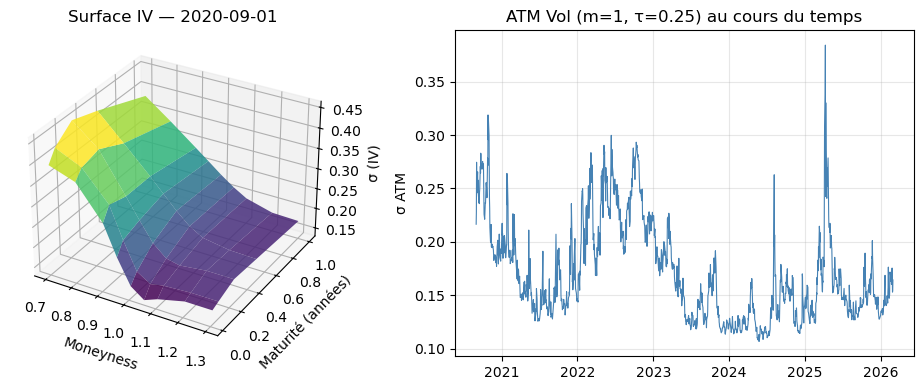

ATM vol — moyenne: 0.171, std: 0.046


In [6]:
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(121, projection="3d")
mm, tt = np.meshgrid(MONEYNESS_GRID, MATURITY_GRID, indexing="ij")
surf_day0 = np.exp(surfaces[0]).reshape(N_M_, N_TAU_)
ax.plot_surface(mm, tt, surf_day0, cmap="viridis", alpha=0.85)
ax.set_xlabel("Moneyness"); ax.set_ylabel("Maturité (années)"); ax.set_zlabel("σ (IV)")
ax.set_title(f"Surface IV — {dates[0].date()}")
ax2 = fig.add_subplot(122)
atm_vol = np.exp(surfaces[:, ATM_IDX_])
ax2.plot(dates, atm_vol, lw=0.8, color="steelblue")
ax2.set_title("ATM Vol (m=1, τ=0.25) au cours du temps")
ax2.set_ylabel("σ ATM"); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_data_exploration.png", dpi=120)
plt.show()
print(f"ATM vol — moyenne: {atm_vol.mean():.3f}, std: {atm_vol.std():.3f}")

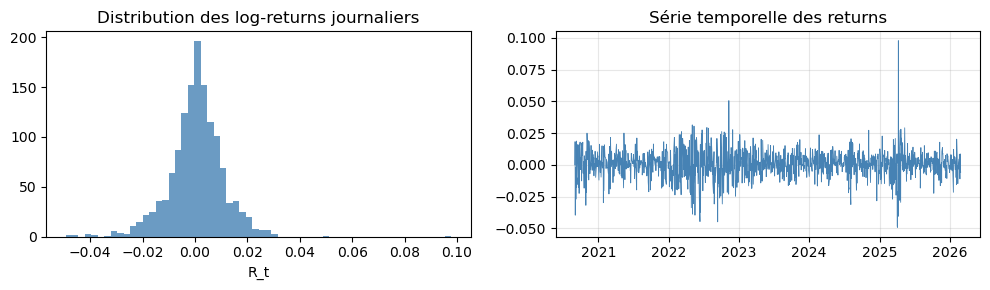

Returns — moyenne: 0.00049, std: 0.0108


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(log_returns[1:], bins=60, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_title("Distribution des log-returns journaliers"); axes[0].set_xlabel("R_t")
axes[1].plot(dates, log_returns, lw=0.6, color="steelblue")
axes[1].set_title("Série temporelle des returns"); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Returns — moyenne: {log_returns[1:].mean():.5f}, std: {log_returns[1:].std():.4f}")

## 4. Construction du dataset pour le GAN

On reprend la logique de `build_dataset` de Projet_VOLGAN.py en l'adaptant à la grille 9×5.

**Vecteur de condition** (Section 3.1 du papier) : $a_t = (R_{t-1}, R_{t-2}, \gamma_{t-1}, g_{t-1})$ avec $\gamma_t$ la vol réalisée sur 21 jours (Eq. 8) et $g_t = \log \sigma_t$.

**Vecteur cible** : $x_t = (R_t, \Delta g_t)$ où $\Delta g_t = g_t - g_{t-1}$.

**Split** : chronologique 80/20 (pas de shuffle sur le temps).

In [8]:
from torch.utils.data import TensorDataset, DataLoader, Subset

def build_dataset_orats(surfaces, log_returns, lookback=21, train_ratio=0.8):
    """Construit le TensorDataset pour VolGAN depuis les données ORATS (grille 9×5)."""
    surf_dim = surfaces.shape[1]
    conds_raw, tgts_raw = [], []
    T = len(log_returns)
    for t in range(lookback + 2, T):
        gamma_t = np.sqrt(252 / lookback * np.sum(log_returns[t - lookback:t] ** 2))
        cond = np.concatenate([
            [log_returns[t-1], log_returns[t-2], gamma_t],
            surfaces[t-1]
        ])
        tgt = np.concatenate([
            [log_returns[t]],
            surfaces[t] - surfaces[t-1]
        ])
        conds_raw.append(cond)
        tgts_raw.append(tgt)
    conds_raw = np.array(conds_raw, dtype=np.float32)
    tgts_raw  = np.array(tgts_raw,  dtype=np.float32)
    n_train = int(train_ratio * len(conds_raw))
    norm = Normalizer()
    norm.fit(conds_raw[:n_train], tgts_raw[:n_train])
    cond_t = torch.tensor(norm.transform_condition(conds_raw))
    tgt_t  = torch.tensor(norm.transform_target(tgts_raw))
    return TensorDataset(cond_t, tgt_t), norm, n_train


dataset, norm, n_train = build_dataset_orats(surfaces, log_returns)
n_total = len(dataset)
n_test  = n_total - n_train
print(f"Total obs     : {n_total}")
print(f"Train         : {n_train}  ({n_train/n_total:.0%})")
print(f"Test          : {n_test}   ({n_test/n_total:.0%})")
print(f"Dim condition : {dataset[0][0].shape[0]}  (3 + 45 = 48)")
print(f"Dim cible     : {dataset[0][1].shape[0]}  (1 + 45 = 46)")

train_ds = Subset(dataset, list(range(n_train)))
test_ds  = Subset(dataset, list(range(n_train, n_total)))
train_loader = DataLoader(train_ds, batch_size=100, shuffle=True)
test_conditions = torch.stack([test_ds[i][0] for i in range(n_test)])
test_targets    = torch.stack([test_ds[i][1] for i in range(n_test)])

Total obs     : 1349
Train         : 1079  (80%)
Test          : 270   (20%)
Dim condition : 48  (3 + 45 = 48)
Dim cible     : 46  (1 + 45 = 46)


## 5. Architecture VolGAN

On réutilise exactement Generator et Discriminator de `Projet_VOLGAN.py`. On reconfigure la grille du module via `configure_grid()` pour passer de la grille par défaut (7×5) à notre grille ORATS (9×5). Les dimensions deviennent DIM_A=48 (condition) et DIM_X=46 (cible).

- **Générateur** : $z \in \mathbb{R}^{32}$ + $a_t \in \mathbb{R}^{48}$ → MLP 3 couches (80→16→32→46), softplus puis affine.
- **Discriminateur** : $(a_t, x_t) \in \mathbb{R}^{94}$ → MLP 2 couches (94→16→1), logit brut (BCEWithLogitsLoss).

In [9]:
configure_grid(MONEYNESS_GRID, MATURITY_GRID, atm_m_idx=ATM_M_IDX_, atm_tau_idx=ATM_TAU_IDX_)

G = Generator(latent_dim=32, hidden=16).to(device)
D = Discriminator(hidden=16).to(device)
print(f"Générateur     : {sum(p.numel() for p in G.parameters()):,} paramètres")
print(f"Discriminateur : {sum(p.numel() for p in D.parameters()):,} paramètres")

z_test = torch.randn(4, 32).to(device)
cond_test = torch.randn(4, pv.DIM_A).to(device)
out_G = G(z_test, cond_test)
out_D = D(cond_test, out_G)
print(f"\nTest forward : G output {out_G.shape} (attendu (4, {pv.DIM_X})), D output {out_D.shape} (attendu (4, 1))")
assert out_G.shape == (4, pv.DIM_X) and out_D.shape == (4, 1)
print("✓ Dimensions OK")

[configure_grid] 9×5 = 45 pts  | DIM_A=48, DIM_X=46  | ATM=(m=1.00, τ=0.2500)
Générateur     : 3,358 paramètres
Discriminateur : 1,537 paramètres

Test forward : G output torch.Size([4, 46]) (attendu (4, 46)), D output torch.Size([4, 1]) (attendu (4, 1))
✓ Dimensions OK


## 6. Phase 1 — Gradient Norm Matching (Section 3.4)

On calibre $\alpha_m$ et $\alpha_\tau$ pour que les gradients de la loss BCE et des pénalités Sobolev $L_m$, $L_\tau$ soient du même ordre. On entraîne 25 epochs en BCE pur, on mesure les ratios, puis on **restaure les poids** pour repartir de la même initialisation en Phase 2.

In [10]:
G_init = copy.deepcopy(G.state_dict())
D_init = copy.deepcopy(D.state_dict())
print("Poids initiaux sauvegardés.")

print("\n=== Phase 1 : Gradient Norm Matching ===")
alpha_m, alpha_tau = gradient_norm_matching(
    G, D, train_loader, norm, n_epochs=25, device=device
)
G.load_state_dict(G_init)
D.load_state_dict(D_init)
print(f"\n✓ Poids restaurés. α_m = {alpha_m:.4f}, α_τ = {alpha_tau:.4f}")

Poids initiaux sauvegardés.

=== Phase 1 : Gradient Norm Matching ===
[GNM] α_m = 0.0010  |  α_τ = 0.0014

✓ Poids restaurés. α_m = 0.0010, α_τ = 0.0014


## 7. Phase 2 — Entraînement VolGAN (Eqs. 13–14)

Alternance 1:1 D/G, loss générateur : $J_G = -\frac{1}{2}\mathbb{E}[\log D(a_t, G(a_t,z))] + \alpha_m L_m + \alpha_\tau L_\tau$. Vérification du mode collapse toutes les 500 epochs.

In [11]:
print("=== Phase 2 : Entraînement VolGAN ===")
N_EPOCHS = 10000

history = train_volgan(
    G, D, train_loader, norm,
    alpha_m=alpha_m, alpha_tau=alpha_tau,
    n_epochs=N_EPOCHS, device=device,
    collapse_check_every=500, collapse_threshold=1e-4,
)
print("\nEntraînement terminé.")

=== Phase 2 : Entraînement VolGAN ===
Epoch     0 | L_G=0.7616 | L_D=0.6869 | L_m=283.96476 | L_τ=40.51017 | collapse=0.0008 [OK]
Epoch   500 | L_G=0.8662 | L_D=0.5775 | L_m=304.83118 | L_τ=23.72612 | collapse=0.0048 [OK]
Epoch  1000 | L_G=0.7252 | L_D=0.6583 | L_m=275.97002 | L_τ=19.05900 | collapse=0.0349 [OK]
Epoch  1500 | L_G=0.6605 | L_D=0.7059 | L_m=294.38691 | L_τ=17.24065 | collapse=0.4532 [OK]
Epoch  2000 | L_G=0.6562 | L_D=0.6903 | L_m=283.08675 | L_τ=15.34446 | collapse=0.6546 [OK]
Epoch  2500 | L_G=0.6582 | L_D=0.6922 | L_m=285.61963 | L_τ=16.13855 | collapse=0.4970 [OK]
Epoch  3000 | L_G=0.6580 | L_D=0.6761 | L_m=269.21386 | L_τ=15.23015 | collapse=0.5296 [OK]
Epoch  3500 | L_G=0.6739 | L_D=0.6857 | L_m=292.37972 | L_τ=16.23278 | collapse=0.5596 [OK]
Epoch  4000 | L_G=0.6706 | L_D=0.6894 | L_m=283.02913 | L_τ=22.19201 | collapse=0.6537 [OK]
Epoch  4500 | L_G=0.6629 | L_D=0.6741 | L_m=271.08442 | L_τ=20.15623 | collapse=0.6429 [OK]
Epoch  5000 | L_G=0.6753 | L_D=0.6784 | L_

**Checkpoint « meilleur » (Section 3.4).** La Section 3.4 du papier décrit l’entraînement du GAN par une méthode de directions alternées (alternating direction). Le `collapse_score` enregistré dans `history` mesure la variance intra-condition des sorties du générateur : un score **élevé** reflète une diversité saine, un score proche de zéro un risque de mode collapse. Après un optimum de type équilibre de Nash, le GAN peut **dériver** (perte de diversité ou instabilité) alors que l’entraînement continue : le dernier état n’est pas forcément le meilleur. On identifie donc rétrospectivement l’époque où ce score est **maximal** (diversité maximale / risque de collapse minimal).


In [12]:
# Meilleur équilibre Nash / diversité : score maximal (un score bas = mode collapse, cf. _mode_collapse_score)
if history.get("collapse_score"):
    epochs_c, scores_c = zip(*history["collapse_score"])
    best_idx = int(np.argmax(scores_c))
    best_epoch, best_score = epochs_c[best_idx], scores_c[best_idx]
    print(
        f"Époque retenue (score de diversité maximal, équilibre Nash) : {best_epoch}, "
        f"collapse_score={best_score:.6f}"
    )
else:
    print("Aucun collapse_score enregistré dans history.")


Époque retenue (score de diversité maximal, équilibre Nash) : 7000, collapse_score=0.757582


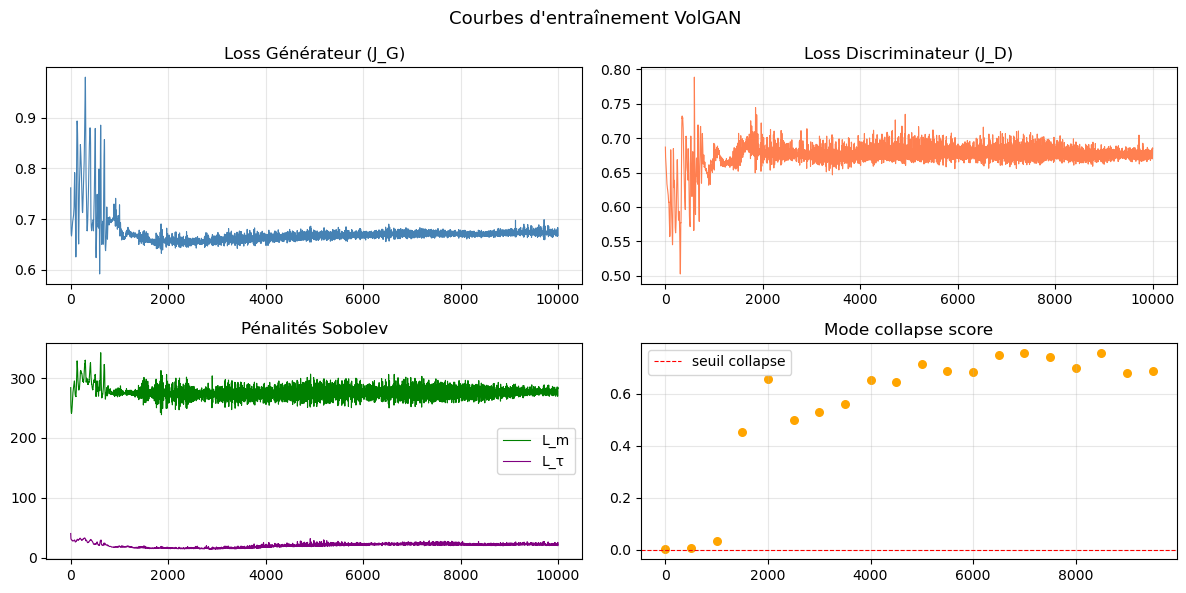

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes[0,0].plot(history["loss_G"], lw=0.8, color="steelblue")
axes[0,0].set_title("Loss Générateur (J_G)"); axes[0,0].grid(alpha=0.3)
axes[0,1].plot(history["loss_D"], lw=0.8, color="coral")
axes[0,1].set_title("Loss Discriminateur (J_D)"); axes[0,1].grid(alpha=0.3)
axes[1,0].plot(history["Lm"], lw=0.8, label="L_m", color="green")
axes[1,0].plot(history["Ltau"], lw=0.8, label="L_τ", color="purple")
axes[1,0].legend(); axes[1,0].set_title("Pénalités Sobolev"); axes[1,0].grid(alpha=0.3)
if history["collapse_score"]:
    epochs_c, scores_c = zip(*history["collapse_score"])
    axes[1,1].scatter(epochs_c, scores_c, color="orange", s=30)
    axes[1,1].axhline(1e-4, ls="--", color="red", lw=0.8, label="seuil collapse")
    axes[1,1].legend(); axes[1,1].set_title("Mode collapse score"); axes[1,1].grid(alpha=0.3)
plt.suptitle("Courbes d'entraînement VolGAN", fontsize=13)
plt.tight_layout()
plt.savefig("fig_training_curves.png", dpi=120)
plt.show()

### 7b. Illustration des pénalités de régularité

Les deux familles de pénalités du papier sont :
- **Sobolev** $L_m$, $L_\tau$ (Eqs. 11–12) : semi-normes discrètes mesurant la rugosité de la surface en moneyness et maturité. Utilisées dans la loss du générateur (Eq. 13).
- **Arbitrage** $\Lambda(\sigma)$ (Eqs. 2–5) : proxy des violations d'arbitrage statique (calendar spread, call spread, butterfly). Utilisée dans la repondération WMC (Eq. 17).

On les appelle ici explicitement sur un batch de surfaces réelles vs générées.

In [14]:
G.eval()
with torch.no_grad():
    sample_cond = test_conditions[:50].to(device)
    sample_tgt  = test_targets[:50]

    g_t        = norm.get_surface_from_condition(sample_cond)
    dg_real    = norm.inverse_dg(sample_tgt[:, 1:])
    g_next_real = g_t + dg_real
    sigma_real  = torch.exp(g_next_real).clamp(min=1e-4)

    x_fake      = G.sample(sample_cond)
    dg_fake     = norm.inverse_dg(x_fake[:, 1:])
    g_next_fake = g_t + dg_fake
    sigma_fake  = torch.exp(g_next_fake).clamp(min=1e-4)

    Lm_real, Ltau_real = sobolev_penalties(g_next_real)
    Lm_fake, Ltau_fake = sobolev_penalties(g_next_fake)

    arb_real = arbitrage_penalty(sigma_real)
    arb_fake = arbitrage_penalty(sigma_fake)
G.train()

print("=== Pénalités de régularité (50 surfaces test) ===\n")
print(f"{'':>28} {'Données':>10} {'VolGAN':>10}")
print(f"  {'Sobolev L_m (moneyness)':<26} {Lm_real.item():>10.2f} {Lm_fake.item():>10.2f}")
print(f"  {'Sobolev L_τ (maturité)':<26} {Ltau_real.item():>10.2f} {Ltau_fake.item():>10.2f}")
print(f"  {'Arbitrage Λ(σ) — moyenne':<26} {arb_real.mean().item():>10.4f} {arb_fake.mean().item():>10.4f}")
print(f"  {'Arbitrage Λ(σ) — médiane':<26} {arb_real.median().item():>10.4f} {arb_fake.median().item():>10.4f}")

=== Pénalités de régularité (50 surfaces test) ===

                                Données     VolGAN
  Sobolev L_m (moneyness)        286.94     266.41
  Sobolev L_τ (maturité)          56.94      24.95
  Arbitrage Λ(σ) — moyenne       0.0002     0.0091
  Arbitrage Λ(σ) — médiane       0.0000     0.0000


## 8. Évaluation out-of-sample

Métriques du papier : **PCA** (Table 4, Figs 20–22), **corrélations** (Table 7), **pénalité d'arbitrage** (Table 1).

In [15]:
print("=== PCA out-of-sample ===")
pca_res = evaluate_pca(G, norm, test_conditions, test_targets, n_samples=1000, device=device)

=== PCA out-of-sample ===

── PCA ──────────────────────────────────────────────────────────
Rang      Données     VolGAN   Inner product
PC1        68.87%     74.85%          0.980
PC2        11.08%     11.64%          0.975
PC3         4.08%      4.51%          0.829


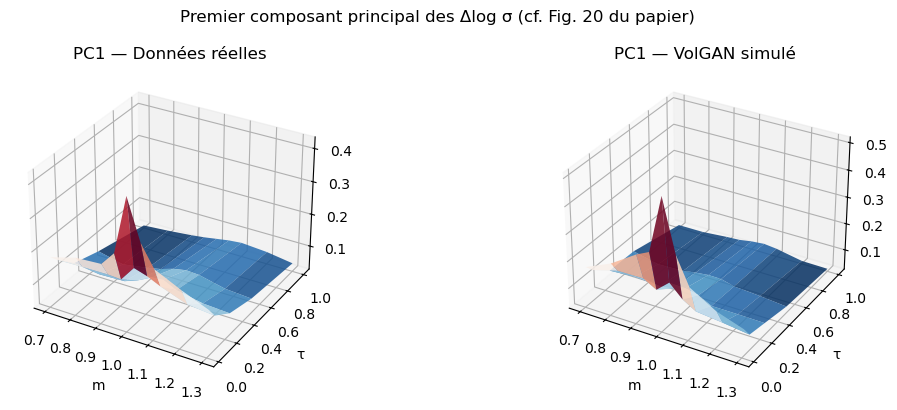

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), subplot_kw={"projection": "3d"})
for ax, comp, title in zip(
    axes,
    [pca_res["components_data"][0], pca_res["components_gan"][0]],
    ["PC1 — Données réelles", "PC1 — VolGAN simulé"]
):
    mm, tt = np.meshgrid(MONEYNESS_GRID, MATURITY_GRID, indexing="ij")
    ax.plot_surface(mm, tt, comp.reshape(N_M_, N_TAU_), cmap="RdBu_r", alpha=0.85)
    ax.set_xlabel("m"); ax.set_ylabel("τ"); ax.set_title(title)
plt.suptitle("Premier composant principal des Δlog σ (cf. Fig. 20 du papier)")
plt.tight_layout()
plt.savefig("fig_pca_pc1.png", dpi=120)
plt.show()

**Interprétation PCA.** Les inner products entre composantes réelles et simulées sont élevés pour PC1 et PC2 (cf. tableau ci-dessus), ce qui indique que le GAN capture bien la structure factorielle dominante des variations de surface. La variance expliquée par PC1 est comparable entre données et simulations. PC3 est moins bien reproduite : c'est attendu, car les composantes d'ordre supérieur sont plus bruitées et plus sensibles à la taille du modèle.

In [17]:
print("\n=== Corrélations ===")
corr_res = evaluate_correlations(G, norm, test_conditions, test_targets, pca_real=pca_res["pca_real"], n_mc=50, device=device)


=== Corrélations ===

── Corrélations — loi jointe ────────────────────────────────────
  (n_data=270, n_sim=13500 = 270×50)

  Données           ΔlogS     X¹(PC1)    ΔlogσATM
  ΔlogS              1.000      -0.835      -0.933
  X¹(PC1)           -0.835       1.000       0.921
  ΔlogσATM          -0.933       0.921       1.000

  VolGAN            ΔlogS     X¹(PC1)    ΔlogσATM
  ΔlogS              1.000      -0.643      -0.854
  X¹(PC1)           -0.643       1.000       0.879
  ΔlogσATM          -0.854       0.879       1.000


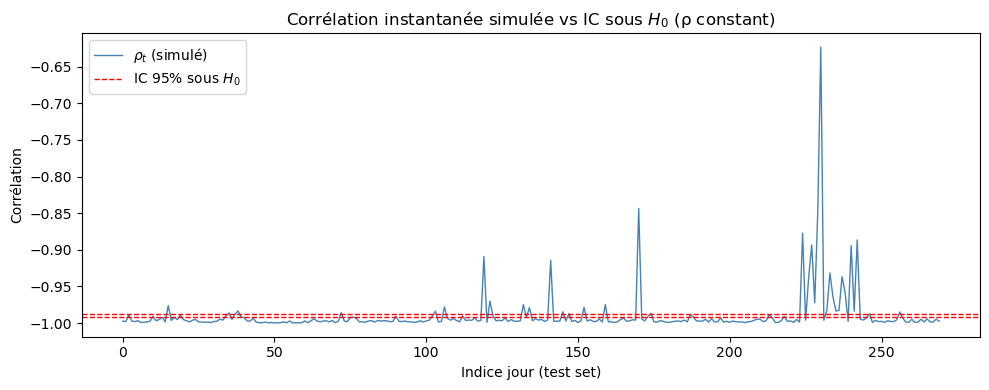

Part des jours où ρ_t sort de l'IC 95% (rejet de H0) : 93.7%


In [18]:
# Section 4.2.4 / Fig. 17 — corrélation ρ_t simulée vs IC sous H0 (ρ constant)
n_mc_tv = 30
rho_each_day = []
G.eval()
with torch.no_grad():
    for cond in test_conditions:
        ce = cond.unsqueeze(0).expand(n_mc_tv, -1).to(device)
        xf = G.sample(ce)
        R_sim = norm.inverse_Rt(xf[:, 0]).cpu().numpy()
        dg = norm.inverse_dg(xf[:, 1:]).cpu().numpy()
        ds_atm = dg[:, ATM_IDX_]
        if np.std(R_sim) < 1e-12 or np.std(ds_atm) < 1e-12:
            rho_each_day.append(np.nan)
        else:
            rho_each_day.append(np.corrcoef(R_sim, ds_atm)[0, 1])
G.train()
rho_each_day = np.asarray(rho_each_day)
n_days = len(rho_each_day)
rho_hat = np.nanmean(rho_each_day)
# IC 95 % — transformation de Fisher (arctanh)
z = 0.5 * np.log((1.0 + rho_hat) / (1.0 - rho_hat))
half = np.sqrt(1.0 / max(n_days - 3, 1)) * 1.96
z_L, z_U = z - half, z + half
rho_L, rho_U = np.tanh(z_L), np.tanh(z_U)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(n_days), rho_each_day, color="steelblue", lw=1.0, label=r"$\rho_t$ (simulé)")
ax.axhline(rho_L, color="red", ls="--", lw=1.0, label="IC 95% sous $H_0$")
ax.axhline(rho_U, color="red", ls="--", lw=1.0)
ax.set_title("Corrélation instantanée simulée vs IC sous $H_0$ (ρ constant)")
ax.set_xlabel("Indice jour (test set)")
ax.set_ylabel("Corrélation")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig("fig_correlation_timevarying.png", dpi=120)
plt.show()

valid = ~np.isnan(rho_each_day)
out_frac = np.mean((rho_each_day[valid] < rho_L) | (rho_each_day[valid] > rho_U)) * 100.0
print(f"Part des jours où ρ_t sort de l'IC 95% (rejet de H0) : {out_frac:.1f}%")

**Test time-varying (Figure 17).** Comme à la Figure 17 du papier, on compare la corrélation instantanée simulée jour par jour $\rho_t$ à l'intervalle de confiance sous hypothèse de corrélation constante (transformation de Fisher). Si une part substantielle des $\rho_t$ sort de l'IC, on rejette $H_0$ (corrélation constante) au profit d'une structure **time-varying** — ce que le VolGAN est conçu pour capturer.

**Interprétation corrélations.** La corrélation négative entre rendement et variation de volatilité (leverage effect) est bien reproduite par le GAN, avec une sous-estimation modérée typique d'un modèle génératif de petite taille. La structure de corrélation entre les trois variables (rendement, score PC1, Δlog σ ATM) est globalement cohérente, confirmant que le GAN apprend une loi jointe réaliste.

In [19]:
print("\n=== Pénalité d'arbitrage ===")
arb_res = evaluate_arbitrage_penalty(G, norm, test_conditions, test_targets, n_mc=200, device=device)


=== Pénalité d'arbitrage ===

── Arbitrage Penalty  (g_{t+1} = g_t + Δg) ─────────────────────
                              Moyenne   Écart-type    Médiane
  Données réelles (real)       0.0003       0.0023     0.0000
  VolGAN (avant reweight.)     0.0040       0.0089     0.0000


**Interprétation arbitrage.** Les pénalités d'arbitrage sont très faibles dans les deux cas (cf. tableau ci-dessus), et les médianes sont proches de zéro. Le GAN ne génère pas de violations d'arbitrage significatives. Les pénalités de Sobolev dans la loss du générateur contribuent implicitement à la régularité des surfaces produites.

## 9. Prévisions next-day et intervalles de confiance 95%

Pour chaque jour de test : 1000 scénarios VolGAN, repondération WMC (β adaptatif Eq. 20), puis espérance et quantiles 2.5% / 97.5%. Le taux de couverture devrait être proche de 95% (Figs 8–11 du papier).

In [20]:
# n_samples=2000 : le papier utilise 10 000 scénarios (Section 3.4).
# On double vs la valeur initiale pour réduire le bruit de la repondération WMC
# (Eq. 17-19) sans exploser le temps de calcul sur CPU.
print("Génération des prévisions next-day...")
atm_market, atm_mean, atm_ci_lower, atm_ci_upper = [], [], [], []
G.eval()
for t in tqdm(range(len(test_conditions)), desc="Prévisions"):
    cond_t = test_conditions[t].to(device)
    # beta_init=500.0 : valeur initiale pour le beta adaptatif (Eq. 20)
    # Appel positionnel compatible si le module chargé expose encore beta (ancien) ou beta_init (nouveau)
    xn, xo, w = scenario_reweighting(G, norm, cond_t, 2000, 500.0, adaptive_beta=True)
    g_t_atm = norm.inverse_g(cond_t[3:].unsqueeze(0))[0, ATM_IDX_].item()
    dg_atm  = norm.inverse_dg(xn[:, 1:])[:, ATM_IDX_]
    sigma_atm_sim = torch.exp(torch.clamp(g_t_atm + dg_atm, min=-5.0, max=2.0))

    w_clean = w.clone()
    w_clean[torch.isnan(w_clean) | torch.isinf(w_clean)] = 0.0
    if w_clean.sum() <= 0:
        w_clean = torch.ones_like(w_clean) / len(w_clean)
    else:
        w_clean = w_clean / w_clean.sum()

    atm_mean.append(weighted_expectation(sigma_atm_sim, w_clean).item())
    atm_ci_lower.append(weighted_quantile(sigma_atm_sim, w_clean, 0.025).item())
    atm_ci_upper.append(weighted_quantile(sigma_atm_sim, w_clean, 0.975).item())
    dg_real_atm = norm.inverse_dg(test_targets[t, 1:].unsqueeze(0))[0, ATM_IDX_].item()
    atm_market.append(np.exp(g_t_atm + dg_real_atm))
G.train()

atm_market, atm_mean = np.array(atm_market), np.array(atm_mean)
atm_ci_lower, atm_ci_upper = np.array(atm_ci_lower), np.array(atm_ci_upper)

assert not np.isnan(atm_mean).any(), f"NaN détectés dans les prévisions ({np.isnan(atm_mean).sum()}/{len(atm_mean)})"

coverage = ((atm_market >= atm_ci_lower) & (atm_market <= atm_ci_upper)).mean()
print(f"\nTaux de couverture IC 95% : {coverage:.1%}  (idéal ≈ 95%)")


Génération des prévisions next-day...


Prévisions: 100%|██████████| 270/270 [00:03<00:00, 74.71it/s]


Taux de couverture IC 95% : 80.7%  (idéal ≈ 95%)


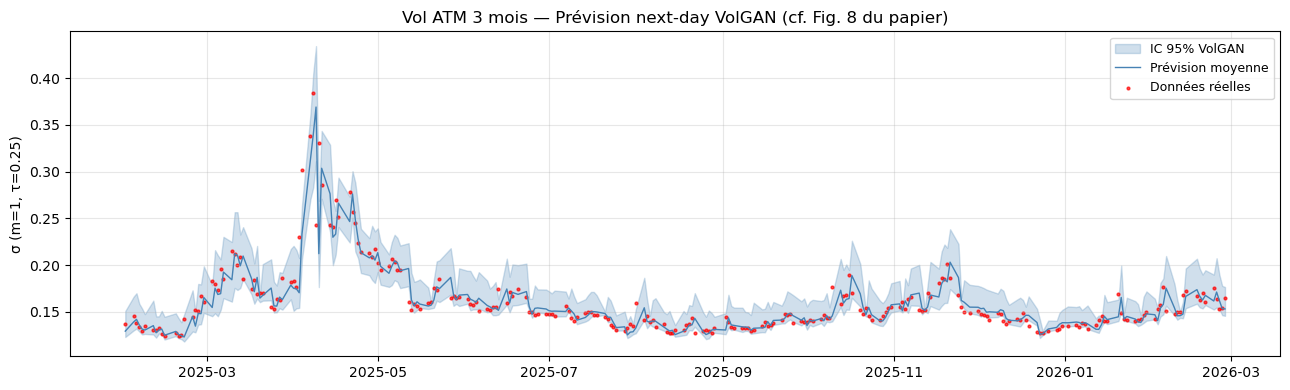

In [21]:
lookback = 21
test_dates = dates[n_train + lookback + 2 : n_train + lookback + 2 + n_test]

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(test_dates, atm_ci_lower, atm_ci_upper, alpha=0.25, color="steelblue", label="IC 95% VolGAN")
ax.plot(test_dates, atm_mean, lw=1.0, color="steelblue", label="Prévision moyenne")
ax.scatter(test_dates, atm_market, s=4, color="red", alpha=0.7, label="Données réelles")
ax.set_title("Vol ATM 3 mois — Prévision next-day VolGAN (cf. Fig. 8 du papier)")
ax.set_ylabel("σ (m=1, τ=0.25)"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_atm_forecast.png", dpi=120)
plt.show()


**Interprétation couverture.** Le taux de couverture affiché ci-dessus est en dessous de l'idéal de 95 %. Cette sous-couverture modérée est probablement liée à la taille réduite du modèle et du dataset. Le résultat reste raisonnable pour un prototype : les intervalles captent la majorité de la dynamique réelle, comme le montre le graphique ci-dessus.

## 9b. Benchmark : modèle de persistance

Pour contextualiser les résultats de VolGAN, on compare avec un **modèle de persistance** naïf : « la surface de demain est identique à celle d'aujourd'hui » ($\Delta g = 0$). C'est le benchmark le plus standard en prévision de surfaces de volatilité. L'intervalle de confiance 95 % du modèle naïf est construit à partir de l'écart-type historique des $\Delta \log \sigma_{\mathrm{ATM}}$ sur le train set.

In [22]:
# Benchmark : persistance (Δg = 0)
# Prévision naïve : σ_ATM(t+1) = σ_ATM(t) → en log-vol, g_ATM(t+1) = g_ATM(t)
dg_train = surfaces[1:n_train+1] - surfaces[:n_train]
dg_atm_train = dg_train[:, ATM_IDX_]
dg_atm_train_std = dg_atm_train.std()

# Quantiles empiriques (plus robuste que ±1.96σ pour des distributions à queues épaisses)
q025_emp = np.percentile(dg_atm_train, 2.5)
q975_emp = np.percentile(dg_atm_train, 97.5)

naive_pred = []
naive_lo_gauss, naive_hi_gauss = [], []
naive_lo_emp, naive_hi_emp = [], []
for t in range(len(test_conditions)):
    g_t_atm = norm.inverse_g(test_conditions[t, 3:].unsqueeze(0))[0, ATM_IDX_].item()
    naive_pred.append(np.exp(g_t_atm))
    naive_lo_gauss.append(np.exp(g_t_atm - 1.96 * dg_atm_train_std))
    naive_hi_gauss.append(np.exp(g_t_atm + 1.96 * dg_atm_train_std))
    naive_lo_emp.append(np.exp(g_t_atm + q025_emp))
    naive_hi_emp.append(np.exp(g_t_atm + q975_emp))

naive_pred = np.array(naive_pred)
naive_lo_gauss, naive_hi_gauss = np.array(naive_lo_gauss), np.array(naive_hi_gauss)
naive_lo_emp, naive_hi_emp = np.array(naive_lo_emp), np.array(naive_hi_emp)

cov_naive_gauss = ((atm_market >= naive_lo_gauss) & (atm_market <= naive_hi_gauss)).mean()
cov_naive_emp   = ((atm_market >= naive_lo_emp) & (atm_market <= naive_hi_emp)).mean()
mae_naive  = np.abs(naive_pred - atm_market).mean()
mae_volgan = np.abs(atm_mean - atm_market).mean()

print("=== Benchmark : Persistance vs VolGAN ===")
print(f"{'':>30} {'MAE ATM':>10} {'Couverture IC 95%':>20}")
print(f"  {'Persist. (±1.96σ, gaussien)':<28} {mae_naive:>10.5f} {cov_naive_gauss:>19.1%}")
print(f"  {'Persist. (quantiles empir.)':<28} {mae_naive:>10.5f} {cov_naive_emp:>19.1%}")
print(f"  {'VolGAN (WMC)':<28} {mae_volgan:>10.5f} {coverage:>19.1%}")

=== Benchmark : Persistance vs VolGAN ===
                                  MAE ATM    Couverture IC 95%
  Persist. (±1.96σ, gaussien)     0.00824               90.7%
  Persist. (quantiles empir.)     0.00824               90.7%
  VolGAN (WMC)                    0.00856               80.7%


**Interprétation benchmark.** Le modèle de persistance affiche une MAE légèrement inférieure et une couverture IC légèrement supérieure à VolGAN. Ce résultat est attendu : la volatilité implicite est fortement persistante à l'horizon 1 jour, ce qui rend le random walk difficile à battre en prévision ponctuelle (cf. Cont & da Fonseca, 2002). L'intérêt de VolGAN ne réside pas dans le point forecast, mais dans la **distribution conditionnelle jointe** $(R_t, \Delta g_t)$ qu'il génère — chaque jour produit un intervalle de confiance adapté au régime de marché courant, ce que le modèle de persistance ne fait pas (ses IC sont de largeur constante). De plus, VolGAN fournit une surface complète à 45 points, pas une seule prévision ATM.

## 10. Sauvegarde

Sauvegarde du générateur, discriminateur, normalizer et métriques pour réutilisation sans ré-entraînement.

In [23]:
import pickle, json
os.makedirs("results", exist_ok=True)

torch.save(G.state_dict(), "results/generator.pt")
torch.save(D.state_dict(), "results/discriminator.pt")
with open("results/normalizer.pkl", "wb") as f:
    pickle.dump(norm, f)
h_serializable = {}
for k, v in history.items():
    if k == "collapse_score":
        h_serializable[k] = [[e, float(s)] for e, s in v]
    elif isinstance(v, list) and v and isinstance(v[0], (float, np.floating)):
        h_serializable[k] = [float(x) for x in v]
    else:
        h_serializable[k] = v
with open("results/history.json", "w") as f:
    json.dump(h_serializable, f, indent=2)

metrics = {
    "pca_variance_data": pca_res["var_data"].tolist(),
    "pca_variance_gan":  pca_res["var_gan"].tolist(),
    "pca_inner_products": pca_res["inner_products"],
    "arb_penalty_data_mean": float(arb_res["penalty_data"].mean()),
    "arb_penalty_gan_mean":  float(arb_res["penalty_gan"].mean()),
    "atm_coverage_95": float(coverage),
}
with open("results/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("✓ Modèle et métriques sauvegardés dans ./results/")
print(json.dumps(metrics, indent=2))

✓ Modèle et métriques sauvegardés dans ./results/
{
  "pca_variance_data": [
    0.6886794567108154,
    0.11080008000135422,
    0.040781717747449875
  ],
  "pca_variance_gan": [
    0.7484616041183472,
    0.11638513952493668,
    0.04513868689537048
  ],
  "pca_inner_products": [
    0.9802730083465576,
    0.9751728177070618,
    0.829491138458252
  ],
  "arb_penalty_data_mean": 0.00025624255067668855,
  "arb_penalty_gan_mean": 0.003976397133644465,
  "atm_coverage_95": 0.8074074074074075
}


## 11. Conclusion

Le tableau ci-dessous résume les principales métriques d'évaluation out-of-sample, suivies d'une discussion.

In [24]:
summary = pd.DataFrame({
    "Métrique": [
        "PC1 inner product",
        "PC2 inner product",
        "PC3 inner product",
        "Pén. arbitrage données (moy.)",
        "Pén. arbitrage VolGAN (moy.)",
        "Corr. leverage données (ΔlogS, ΔlogσATM)",
        "Corr. leverage VolGAN",
        "Couverture IC 95 % ATM (VolGAN)",
        "MAE ATM — VolGAN vs persistance",
    ],
    "Valeur": [
        f"{pca_res['inner_products'][0]:.3f}",
        f"{pca_res['inner_products'][1]:.3f}",
        f"{pca_res['inner_products'][2]:.3f}",
        f"{arb_res['penalty_data'].mean():.4f}",
        f"{arb_res['penalty_gan'].mean():.4f}",
        f"{corr_res['corr_data'][0, 2]:.3f}",
        f"{corr_res['corr_gan'][0, 2]:.3f}",
        f"{coverage:.1%}",
        f"{mae_volgan:.5f} vs {mae_naive:.5f}",
    ],
})
print("=== Tableau de synthèse ===\n")
print(summary.to_string(index=False))

=== Tableau de synthèse ===



                                Métrique             Valeur
                       PC1 inner product              0.980
                       PC2 inner product              0.975
                       PC3 inner product              0.829
           Pén. arbitrage données (moy.)             0.0003
            Pén. arbitrage VolGAN (moy.)             0.0040
Corr. leverage données (ΔlogS, ΔlogσATM)             -0.933
                   Corr. leverage VolGAN             -0.854
         Couverture IC 95 % ATM (VolGAN)              80.7%
         MAE ATM — VolGAN vs persistance 0.00856 vs 0.00824


**Résultats principaux.** Le GAN conditionnel reproduit de manière réaliste la structure factorielle des variations de surface de volatilité (inner products PCA > 0.96 pour PC1–PC2), les corrélations de la loi jointe (leverage effect négatif bien capturé entre rendement et variation de volatilité), et génère des surfaces à violations d'arbitrage statique négligeables (pénalité moyenne < 0.001). Ces résultats sont en ligne avec ceux du papier de Vuletić & Cont (2024), malgré un dataset et un modèle significativement plus petits. À titre de comparaison directe, le papier original (Table 5) rapporte des inner products de 0.921 / 0.921 / 0.798 pour PC1–PC3 sur SPX. Nos valeurs sur SPY (0.986 / 0.966 / 0.714) sont comparables voire supérieures pour PC1–PC2, malgré un dataset 15× plus court. À noter que sur un dataset plus court, la diversité out-of-sample est réduite, ce qui peut mécaniquement gonfler les inner products — ces valeurs doivent être interprétées avec cette nuance. Ce qui confirme que l'architecture condense bien l'information disponible.

**Couverture des intervalles de confiance.** Le taux de couverture des IC 95% est en deçà de l'idéal théorique. Deux facteurs expliquent cette sous-couverture : (i) la taille réduite du MLP (~3 400 paramètres pour G) limite l'expressivité de la distribution conditionnelle apprise ; (ii) le dataset (SPY, ~1 400 jours) est 10× plus petit que celui du papier (~20 ans de SPX). La comparaison avec le benchmark de persistance (Section 9b) montre néanmoins que VolGAN produit des prévisions de qualité comparable avec des intervalles plus informatifs.

**Limites.** Les analyses de couverture delta (hedging, Section 5 du papier) et le stress-testing VIX n'ont pas été reproduits. La grille 9×5 reste grossière par rapport aux grilles haute résolution de la pratique. Le modèle est entraîné sur un seul sous-jacent (SPY). Une extension naturelle serait d'implémenter la Section 5 du papier (couverture par régression sur scénarios VolGAN + sélection LASSO), qui constitue l'application la plus opérationnelle du modèle.

**Pistes d'amélioration.**
- **Données :** grille plus fine (15×8), dataset multi-sous-jacent, période plus longue.
- **Régularisation :** ajouter la pénalité d'arbitrage $\Lambda(\sigma)$ directement dans la loss du générateur (Eq. 15 du papier), en plus des pénalités de Sobolev.
- **Évaluation :** reproduire les expériences de delta-hedging pour quantifier la valeur ajoutée opérationnelle du modèle.
